In [28]:
# Main
import numpy as np
from scipy import stats
import pandas as pd

# Visualizations
import matplotlib.pyplot as plt
import seaborn as sns

# Split and Cross Val
from sklearn.model_selection import train_test_split, GridSearchCV

# Preprocess and Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Models
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge, Lasso, RidgeCV, LassoCV
from sklearn.svm import SVC
from sklearn.cluster import KMeans

# Ensemble Models
from sklearn.ensemble import RandomForestRegressor, GradientBoostingClassifier, RandomForestClassifier
from xgboost import XGBRegressor, XGBClassifier

# Metrics
from sklearn.metrics import (mean_absolute_error, 
                             accuracy_score, 
                             root_mean_squared_error, 
                             r2_score, 
                             mean_absolute_error,
                             mean_squared_error, 
                             silhouette_score)

# Environments and serialization
import joblib

# Datasets
from sklearn.datasets import load_diabetes

In [29]:
heavy_df = pd.read_csv('data/spacex_web_scraped.csv')

In [30]:
heavy_df.head()

,Flight No.,Launch site,Payload,Payload mass,Orbit,Customer,Launch outcome,Date,Time,Version Booster,Booster landing
0,1,Cape Canaveral,Dragon Spacecraft Qualification Unit,U,LEO,SpaceX,Success,4 June 2010,18:45,F9v1.0,Failure (parachute)
1,2,Cape Canaveral,SpaceX COTS Demo Flight 1,U,LEO,NASA,Success,8 December 2010,15:43,F9v1.0,Failure (parachute)
2,3,Cape Canaveral,SpaceX COTS Demo Flight 2,525 kg,LEO,NASA,Success,22 May 2012,07:44,F9 v1.0,No attempt
3,4,Cape Canaveral,SpaceX CRS-1,"4,700 kg",LEO,NASA,Success,8 October 2012,00:35,F9 v1.0,No attempt
4,5,Cape Canaveral,SpaceX CRS-2,"4,877 kg",LEO,NASA,Success,1 March 2013,15:10,F9 v1.0,No attempt


In [31]:
heavy_df['Year']= heavy_df['Date'].str.slice(-4).astype(int)

In [32]:
heavy_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 612 entries, 0 to 611
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Flight No.       612 non-null    int64 
 1   Launch site      612 non-null    object
 2   Payload          609 non-null    object
 3   Payload mass     612 non-null    object
 4   Orbit            610 non-null    object
 5   Customer         598 non-null    object
 6   Launch outcome   612 non-null    object
 7   Date             612 non-null    object
 8   Time             612 non-null    object
 9   Version Booster  612 non-null    object
 10  Booster landing  612 non-null    object
 11  Year             612 non-null    int64 
dtypes: int64(2), object(10)
memory usage: 57.5+ KB


In [33]:
heavy_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 612 entries, 0 to 611
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Flight No.       612 non-null    int64 
 1   Launch site      612 non-null    object
 2   Payload          609 non-null    object
 3   Payload mass     612 non-null    object
 4   Orbit            610 non-null    object
 5   Customer         598 non-null    object
 6   Launch outcome   612 non-null    object
 7   Date             612 non-null    object
 8   Time             612 non-null    object
 9   Version Booster  612 non-null    object
 10  Booster landing  612 non-null    object
 11  Year             612 non-null    int64 
dtypes: int64(2), object(10)
memory usage: 57.5+ KB


In [34]:
heavy_df['Launch outcome'].value_counts()

Launch outcome
Success    610
Failure      2
Name: count, dtype: int64

In [35]:
heavy_df['Booster landing'].value_counts()

Booster landing
Success ( OCISLY           161
Success ( JRTI             121
Success ( ASOG             117
Success                     91
Success ( LZ‑1              38
Success ( LZ‑4              26
No attempt                  18
No attempt                   9
Success ( LZ‑2               7
Controlled (ocean)           6
Failure ( OCISLY             5
Failure ( JRTI               4
Failure (parachute)          2
Failure (ocean)              2
Failure ( LZ‑1               1
Success( JRTI                1
Precluded  (drone ship)      1
Failure ( ASOG               1
Success ( LZ‑40              1
Name: count, dtype: int64

In [36]:
heavy_df.head()

,Flight No.,Launch site,Payload,Payload mass,Orbit,Customer,Launch outcome,Date,Time,Version Booster,Booster landing,Year
0,1,Cape Canaveral,Dragon Spacecraft Qualification Unit,U,LEO,SpaceX,Success,4 June 2010,18:45,F9v1.0,Failure (parachute),2010
1,2,Cape Canaveral,SpaceX COTS Demo Flight 1,U,LEO,NASA,Success,8 December 2010,15:43,F9v1.0,Failure (parachute),2010
2,3,Cape Canaveral,SpaceX COTS Demo Flight 2,525 kg,LEO,NASA,Success,22 May 2012,07:44,F9 v1.0,No attempt,2012
3,4,Cape Canaveral,SpaceX CRS-1,"4,700 kg",LEO,NASA,Success,8 October 2012,00:35,F9 v1.0,No attempt,2012
4,5,Cape Canaveral,SpaceX CRS-2,"4,877 kg",LEO,NASA,Success,1 March 2013,15:10,F9 v1.0,No attempt,2013


In [37]:
heavy_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 612 entries, 0 to 611
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Flight No.       612 non-null    int64 
 1   Launch site      612 non-null    object
 2   Payload          609 non-null    object
 3   Payload mass     612 non-null    object
 4   Orbit            610 non-null    object
 5   Customer         598 non-null    object
 6   Launch outcome   612 non-null    object
 7   Date             612 non-null    object
 8   Time             612 non-null    object
 9   Version Booster  612 non-null    object
 10  Booster landing  612 non-null    object
 11  Year             612 non-null    int64 
dtypes: int64(2), object(10)
memory usage: 57.5+ KB


In [38]:
heavy_df.sample()

,Flight No.,Launch site,Payload,Payload mass,Orbit,Customer,Launch outcome,Date,Time,Version Booster,Booster landing,Year
395,396,Kennedy,Optus,"~4,000 kg",GTO,Optus,Success,"November 17, 2024",22:28,F9B5,Success ( ASOG,2024


In [39]:
heavy_df['Year'].value_counts(sort=False)

Year
2010      2
2012      2
2013      3
2014      6
2015      7
2016      8
2017     18
2018     20
2019     11
2020     26
2021     31
2022     60
2023     88
2024    135
2025    165
2026     30
Name: count, dtype: int64

In [40]:
per_site = heavy_df.groupby('Year')['Launch site'].value_counts()
per_site

Year  Launch site   
2010  Cape Canaveral     2
2012  Cape Canaveral     2
2013  Cape Canaveral     2
      Vandenberg         1
2014  Cape Canaveral     6
2015  Cape Canaveral     7
2016  Cape Canaveral     7
      Vandenberg         1
2017  Kennedy           12
      Vandenberg         5
      Cape Canaveral     1
2018  Cape Canaveral    12
      Vandenberg         6
      Kennedy            2
2019  Cape Canaveral     8
      Vandenberg         2
      Kennedy            1
2020  Cape Canaveral    14
      Kennedy           11
      Vandenberg         1
2021  Cape Canaveral    16
      Kennedy           12
      Vandenberg         3
2022  Cape Canaveral    30
      Kennedy           17
      Vandenberg        13
2023  Cape Canaveral    51
      Vandenberg        26
      Kennedy           11
2024  Cape Canaveral    64
      Vandenberg        47
      Kennedy           24
2025  Cape Canaveral    74
      Vandenberg        64
      Kennedy           27
2026  Cape Canaveral    16
      V

In [41]:
import pandas as pd

# -----------------------------
# 1. LAUNCHES PER YEAR + SITE
# -----------------------------
per_site = (
    heavy_df.groupby("Year")["Launch site"]
    .value_counts()
    .unstack(fill_value=0)
)

# keep only sites you care about
per_site = per_site[["Vandenberg", "Cape Canaveral"]]

print("Launches per year:")
print(per_site)

# -----------------------------
# 2. GET 2026 DATA (PARTIAL YEAR)
# -----------------------------
vbg_2026_so_far = per_site.loc[2026, "Vandenberg"] if 2026 in per_site.index else 0
cape_2026_so_far = per_site.loc[2026, "Cape Canaveral"] if 2026 in per_site.index else 0

# -----------------------------
# 3. FIND LATEST MONTH IN 2026
# -----------------------------
heavy_df["Date"] = pd.to_datetime(heavy_df["Date"], format="mixed", errors="coerce")

latest_month_2026 = heavy_df[heavy_df["Year"] == 2026]["Date"].dt.month.max()



Launches per year:
Launch site  Vandenberg  Cape Canaveral
Year                                   
2010                  0               2
2012                  0               2
2013                  1               2
2014                  0               6
2015                  0               7
2016                  1               7
2017                  5               1
2018                  6              12
2019                  2               8
2020                  1              14
2021                  3              16
2022                 13              30
2023                 26              51
2024                 47              64
2025                 64              74
2026                 14              16


In [42]:
vandy_df = (
    heavy_df.groupby("Year")["Launch site"]
    .value_counts()
    .unstack(fill_value=0)[["Vandenberg"]]
    .reset_index()
)

vandy_df.columns = ["Year", "Launches"]

print(vandy_df)

    Year  Launches
0   2010         0
1   2012         0
2   2013         1
3   2014         0
4   2015         0
5   2016         1
6   2017         5
7   2018         6
8   2019         2
9   2020         1
10  2021         3
11  2022        13
12  2023        26
13  2024        47
14  2025        64
15  2026        14


In [43]:
cape_df = (
    heavy_df.groupby("Year")["Launch site"]
    .value_counts()
    .unstack(fill_value=0)
)

# combine Cape + Kennedy
cape_df["Cape_Total"] = cape_df["Cape Canaveral"] + cape_df["Kennedy"]

# keep only what you need
cape_df = cape_df[["Cape_Total"]].reset_index()
cape_df.columns = ["Year", "Launches"]

print(cape_df)

    Year  Launches
0   2010         2
1   2012         2
2   2013         2
3   2014         6
4   2015         7
5   2016         7
6   2017        13
7   2018        14
8   2019         9
9   2020        25
10  2021        28
11  2022        47
12  2023        62
13  2024        88
14  2025       101
15  2026        16


In [44]:
X = vandy_df[["Year"]]
y = vandy_df["Launches"]

In [45]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

In [46]:
forest_model = RandomForestRegressor(n_estimators=100, random_state=42)
forest_model.fit(X_train, y_train)
y_pred_forest = forest_model.predict(X_test)
y_pred_forest


array([ 0.78,  0.78,  1.27, 33.21])

In [47]:
print("Forest:", mean_absolute_error(y_test, y_pred_forest))


Forest: 8.155


In [48]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import PolynomialFeatures

# 1. Prepare the data you provided for Vandenberg
data = {
    'Year': [2022, 2023, 2024, 2025],
    'Launches': [13, 26, 47, 64]
}
df = pd.DataFrame(data)

# Features (X) must be 2D for scikit-learn
X = df['Year'].values.reshape(-1, 1)
y = df['Launches'].values

# Define the future years we want to predict
future_years = np.array([2026, 2027, 2028, 2029, 2030]).reshape(-1, 1)

# --- MODEL 1: LINEAR REGRESSION ---
# Good for finding a steady, straight-line trend
lr_model = LinearRegression()
lr_model.fit(X, y)
lr_predictions = lr_model.predict(future_years)

# --- MODEL 2: RANDOM FOREST ---
# Good for complex patterns, but limited to the range of historical data
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X, y)
rf_predictions = rf_model.predict(future_years)

# --- MODEL 3: POLYNOMIAL REGRESSION (Degree 2) ---
# Used to capture the "Acceleration" (the hockey-stick curve)
poly_features = PolynomialFeatures(degree=2)
X_poly = poly_features.fit_transform(X)

poly_model = LinearRegression()
poly_model.fit(X_poly, y)

# Transform future years to polynomial format and predict
future_years_poly = poly_features.transform(future_years)
poly_predictions = poly_model.predict(future_years_poly)

# 2. Combine results into a clean table
results = pd.DataFrame({
    'Year': future_years.flatten(),
    'Linear (Steady)': lr_predictions.round(1),
    'Random Forest (Cautious)': rf_predictions.round(1),
    'Polynomial (Accelerated)': poly_predictions.round(1)
})

print("--- SpaceX Vandenberg Launch Predictions ---")
print(results.to_string(index=False))

# Optional: Show the growth rate used by the Linear Model
print(f"\nCalculated Annual Growth Rate (Linear): {lr_model.coef_[0]:.2f} launches per year.")

--- SpaceX Vandenberg Launch Predictions ---
 Year  Linear (Steady)  Random Forest (Cautious)  Polynomial (Accelerated)
 2026             81.0                      57.6                      86.0
 2027             98.4                      57.6                     109.4
 2028            115.8                      57.6                     134.8
 2029            133.2                      57.6                     162.2
 2030            150.6                      57.6                     191.6

Calculated Annual Growth Rate (Linear): 17.40 launches per year.


In [49]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# 1. Setup the Vandenberg Data
data = {
    'Year': [2022, 2023, 2024, 2025],
    'Launches': [13, 26, 47, 64]
}
v_df = pd.DataFrame(data)

# Features (X) and Target (y)
X = df['Year'].values.reshape(-1, 1)
y = df['Launches'].values

# Years to predict
future_years = np.array([2026, 2027, 2028, 2029, 2030]).reshape(-1, 1)

# --- 2. Model Initialization & Training ---

# Linear Regression (Straight line)
lr = LinearRegression().fit(X, y)

# Polynomial Regression (Degree 2 - Acceleration)
poly_feat = PolynomialFeatures(degree=2)
X_poly = poly_feat.fit_transform(X)
poly_model = LinearRegression().fit(X_poly, y)

# Decision Tree (Logic-based splits)
dt = DecisionTreeRegressor(random_state=42).fit(X, y)

# Random Forest (Ensemble of trees)
rf = RandomForestRegressor(n_estimators=100, random_state=42).fit(X, y)

# Gradient Boosting (Sequential error correction)
gb = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42).fit(X, y)

# --- 3. Generate Predictions ---

lr_preds = lr.predict(future_years)
poly_preds = poly_model.predict(poly_feat.transform(future_years))
dt_preds = dt.predict(future_years)
rf_preds = rf.predict(future_years)
gb_preds = gb.predict(future_years)

# --- 4. Display Results ---

results = pd.DataFrame({
    'Year': future_years.flatten(),
    'Linear': lr_preds.round(1),
    'Polynomial': poly_preds.round(1),
    'Decision Tree': dt_preds.round(1),
    'Random Forest': rf_preds.round(1),
    'Gradient Boosting': gb_preds.round(1)
})

print("--- SpaceX Vandenberg Launch Predictions (2026-2030) ---")
print(results.to_string(index=False))

# Quick Insight for your speech:
print("\nModel Insights:")
print(f"- Highest Prediction (Polynomial): {poly_preds[-1]:.1f} launches by 2030 (Captures Growth)")
print(f"- Lowest Prediction (Linear): {lr_preds[-1]:.1f} launches by 2030 (Captures Average)")
print(f"- AI Tree-based Limit: {gb_preds[-1]:.1f} launches (Stuck at historical maximum)")

--- SpaceX Vandenberg Launch Predictions (2026-2030) ---
 Year  Linear  Polynomial  Decision Tree  Random Forest  Gradient Boosting
 2026    81.0        86.0           64.0           57.6               64.0
 2027    98.4       109.4           64.0           57.6               64.0
 2028   115.8       134.8           64.0           57.6               64.0
 2029   133.2       162.2           64.0           57.6               64.0
 2030   150.6       191.6           64.0           57.6               64.0

Model Insights:
- Highest Prediction (Polynomial): 191.6 launches by 2030 (Captures Growth)
- Lowest Prediction (Linear): 150.6 launches by 2030 (Captures Average)
- AI Tree-based Limit: 64.0 launches (Stuck at historical maximum)


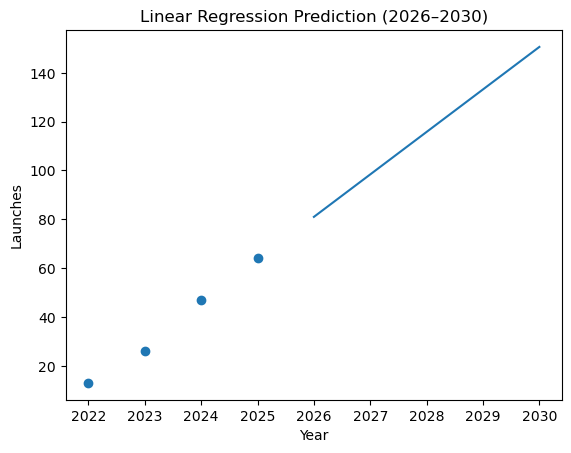

Predictions:
2026: 81.0
2027: 98.4
2028: 115.8
2029: 133.2
2030: 150.6


In [50]:
plt.figure()
plt.scatter(v_df['Year'], df['Launches'])          # actual data
plt.plot(future_years, lr_preds)
plt.xlabel("Year")
plt.ylabel("Launches")
plt.title("Linear Regression Prediction (2026–2030)")
plt.show()

# Print predictions
print("Predictions:")
for year, pred in zip(future_years.flatten(), lr_preds):
    print(f"{year}: {pred:.1f}")

In [51]:
# 1. Setup the Cape Data
data = {
    'Year': [2020, 2021, 2022, 2023, 2024, 2025],
    'Launches': [25, 28, 47, 62, 88, 101]
}
df = pd.DataFrame(data)

# Features (X) and Target (y)
X = df['Year'].values.reshape(-1, 1)
y = df['Launches'].values

# Years to predict
future_years = np.array([2026, 2027, 2028, 2029, 2030]).reshape(-1, 1)

# --- 2. Model Initialization & Training ---

# Linear Regression (Straight line)
lr = LinearRegression().fit(X, y)

# Polynomial Regression (Degree 2 - Acceleration)
poly_feat = PolynomialFeatures(degree=2)
X_poly = poly_feat.fit_transform(X)
poly_model = LinearRegression().fit(X_poly, y)

# Decision Tree (Logic-based splits)
dt = DecisionTreeRegressor(random_state=42).fit(X, y)

# Random Forest (Ensemble of trees)
rf = RandomForestRegressor(n_estimators=100, random_state=42).fit(X, y)

# Gradient Boosting (Sequential error correction)
gb = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42).fit(X, y)

# --- 3. Generate Predictions ---

lr_preds = lr.predict(future_years)
poly_preds = poly_model.predict(poly_feat.transform(future_years))
dt_preds = dt.predict(future_years)
rf_preds = rf.predict(future_years)
gb_preds = gb.predict(future_years)

# --- 4. Display Results ---

results = pd.DataFrame({
    'Year': future_years.flatten(),
    'Linear': lr_preds.round(1),
    'Polynomial': poly_preds.round(1),
    'Decision Tree': dt_preds.round(1),
    'Random Forest': rf_preds.round(1),
    'Gradient Boosting': gb_preds.round(1)
})

print("--- SpaceX Cape Launch Predictions (2026-2030) ---")
print(results.to_string(index=False))

# Quick Insight for your speech:
print("\nModel Insights:")
print(f"- Highest Prediction (Polynomial): {poly_preds[-1]:.1f} launches by 2030 (Captures Growth)")
print(f"- Lowest Prediction (Linear): {lr_preds[-1]:.1f} launches by 2030 (Captures Average)")
print(f"- AI Tree-based Limit: {gb_preds[-1]:.1f} launches (Stuck at historical maximum)")

--- SpaceX Cape Launch Predictions (2026-2030) ---
 Year  Linear  Polynomial  Decision Tree  Random Forest  Gradient Boosting
 2026   116.0       129.0          101.0           94.8              101.0
 2027   132.4       156.6          101.0           94.8              101.0
 2028   148.9       186.9          101.0           94.8              101.0
 2029   165.3       220.1          101.0           94.8              101.0
 2030   181.7       256.0          101.0           94.8              101.0

Model Insights:
- Highest Prediction (Polynomial): 256.0 launches by 2030 (Captures Growth)
- Lowest Prediction (Linear): 181.7 launches by 2030 (Captures Average)
- AI Tree-based Limit: 101.0 launches (Stuck at historical maximum)


In [52]:
print(cape_df)

    Year  Launches
0   2010         2
1   2012         2
2   2013         2
3   2014         6
4   2015         7
5   2016         7
6   2017        13
7   2018        14
8   2019         9
9   2020        25
10  2021        28
11  2022        47
12  2023        62
13  2024        88
14  2025       101
15  2026        16


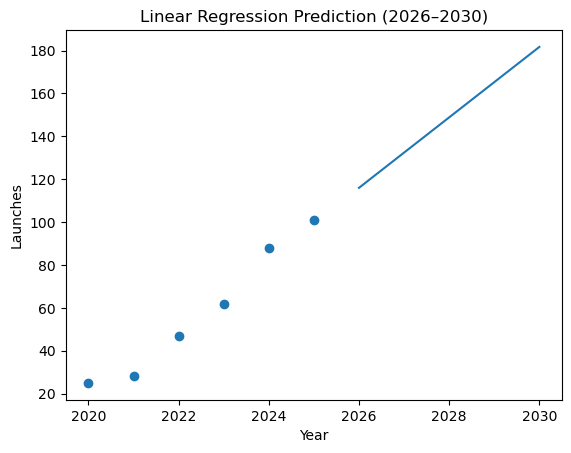

Predictions:
2026: 116.0
2027: 132.4
2028: 148.9
2029: 165.3
2030: 181.7


In [53]:
plt.figure()
plt.scatter(df['Year'], df['Launches'])          # actual data
plt.plot(future_years, lr_preds)
plt.xlabel("Year")
plt.ylabel("Launches")
plt.title("Linear Regression Prediction (2026–2030)")
plt.show()

# Print predictions
print("Predictions:")
for year, pred in zip(future_years.flatten(), lr_preds):
    print(f"{year}: {pred:.1f}")